In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [3]:
import sys
sys.path.append("/home/563/as8561/side_projects/extreme_el_nino_2026/")

In [4]:
from functions import preproc_funcs as funcs

In [5]:
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/historical/r10i1p1f1/Amon/ts/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/piControl/r1i1p1f1/Amon/ts/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/ScenarioMIP/**/**/ssp585/r10i1p1f1/Amon/tas/gn/**/*.nc')
# xr.open_dataset('/g/data/**/replicas/CMIP6/CMIP/**/**/abrupt-4xCO2/r1i1p1f1/Amon/ts/gn/**/*.nc')

In [6]:
import gzip
from pathlib import Path


In [7]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

    # --- type sizes: consistent hierarchy (title > labels > ticks/legend) ---
    "font.size":        9,
    "axes.titlesize":   11,
    "axes.labelsize":   10,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "figure.titlesize": 12,

    # --- lines & ticks: slightly heavier so they hold up next to bigger text ---
    "axes.linewidth":    0.8,
    "lines.linewidth":   1.2,
    "patch.linewidth":   0.8,
    "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.major.size":  3.0, "ytick.major.size":  3.0,
    "xtick.minor.width": 0.6, "ytick.minor.width": 0.6,
    "xtick.minor.size":  1.8, "ytick.minor.size":  1.8,
    "xtick.direction": "out", "ytick.direction": "out",

    # --- spines & legend ---
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlepad": 6, "axes.labelpad": 4,
    "legend.frameon": False,
    "legend.handletextpad": 0.4,
    "legend.labelspacing": 0.35,

    # --- output ---
    "figure.dpi": 150, "savefig.dpi": 600,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,   # editable text in Illustrator
})

MM = 1/25.4
SINGLE_COL = 89  * MM
DOUBLE_COL = 183 * MM

In [8]:
def set_scale(mode="draft"):
    s = {"draft": 1.0, "submit": 0.85}[mode]      # 0.7 → ~7pt base, 7.7pt title
    mpl.rcParams.update({
        "font.size": 9*s, "axes.titlesize": 11*s, "axes.labelsize": 10*s,
        "xtick.labelsize": 9*s, "ytick.labelsize": 9*s, "legend.fontsize": 9*s,
    })
set_scale("submit")

##  ingest observation data

In [9]:
obs_dir = Path("/g/data/if69/as8561/data/obs_SST_products")

obs_files = {
    "COBE":    obs_dir / "COBE_sst.mon.mean.nc",
    "DCSST":   obs_dir / "DCSST-I_mean_1x1.nc",
    "HadISST": obs_dir / "HadISST_sst.nc.gz",   # gzipped
    "HadSST4": obs_dir / "HadSST.4.2.0.0_actuals_median.nc",
    "ERSSTv5": obs_dir / "ersst_v5.nc",
}

def open_obs(name, path):
    """Open one obs product; eagerly load the gzipped HadISST (scipy backend can't lazily index)."""
    if str(path).endswith(".gz"):
        with gzip.open(path) as f:
            return xr.open_dataset(f).load()      # .load() materializes it in memory
    return xr.open_dataset(path)

for name, path in obs_files.items():
    try:
        ds = open_obs(name, path)
        print(f"===== {name} =====")
        print("data vars :", list(ds.data_vars))
        print("coords    :", list(ds.coords))
        print("dims      :", dict(ds.sizes))
        # peek at lat/lon naming + range and time span
        latname = [c for c in ds.coords if c.lower() in ("lat","latitude","y")]
        lonname = [c for c in ds.coords if c.lower() in ("lon","longitude","x")]
        if latname: print("lat       :", latname[0], float(ds[latname[0]].min()), "→", float(ds[latname[0]].max()))
        if lonname: print("lon       :", lonname[0], float(ds[lonname[0]].min()), "→", float(ds[lonname[0]].max()))
        if "time" in ds.coords:
            print("time      :", str(ds.time.values[0])[:10], "→", str(ds.time.values[-1])[:10], "| n =", ds.sizes.get("time"))
        print()
        ds.close()
    except Exception as e:
        print(f"===== {name} ===== FAILED: {type(e).__name__}: {e}\n")

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


===== COBE =====
data vars : ['sst']
coords    : ['lat', 'lon', 'time']
dims      : {'lat': 180, 'lon': 360, 'time': 2118}
lat       : lat -89.5 → 89.5
lon       : lon 0.5 → 359.5
time      : 1850-01-01 → 2026-06-01 | n = 2118

===== DCSST =====
data vars : ['sst']
coords    : ['lon', 'lat', 'time']
dims      : {'lon': 360, 'lat': 180, 'time': 2100}
lat       : lat -89.5 → 89.5
lon       : lon 0.5 → 359.5
time      : 1850-01-16 → 2024-12-16 | n = 2100

===== HadISST =====
data vars : ['time_bnds', 'sst']
coords    : ['time', 'latitude', 'longitude']
dims      : {'time': 1877, 'nv': 2, 'latitude': 180, 'longitude': 360}
lat       : latitude -89.5 → 89.5
lon       : longitude -179.5 → 179.5
time      : 1870-01-16 → 2026-05-16 | n = 1877

===== HadSST4 =====
data vars : ['tos', 'time_bnds', 'latitude_bnds', 'longitude_bnds']
coords    : ['time', 'latitude', 'longitude']
dims      : {'time': 2118, 'latitude': 36, 'longitude': 72, 'bnds': 2}
lat       : latitude -87.5 → 87.5
lon       : lon

In [10]:
def standardize(ds):
    """Return a clean SST DataArray: dims (time, lat, lon), lon in 0–360, lat ascending."""
    varname = "tos" if "tos" in ds.data_vars else "sst"
    da = ds[varname]

    # unify coord names
    ren = {}
    for c in list(da.coords):
        cl = c.lower()
        if cl in ("latitude", "y"):  ren[c] = "lat"
        if cl in ("longitude", "x"): ren[c] = "lon"
    da = da.rename(ren)

    da = da.squeeze(drop=True)                       # drop any singleton lev/nbnds
    da = da.assign_coords(lon=(da.lon % 360)).sortby("lon")   # → 0–360
    da = da.sortby("lat")                            # ensure ascending
    da = da.where((da > -50) & (da < 50))            # mask land/ice fill values
    return da

sst = {}
for name, path in obs_files.items():
    sst[name] = standardize(open_obs(name, path))
    print(f"{name:8s}  {sst[name].name:4s}  dims={dict(sst[name].sizes)}  "
          f"lon {float(sst[name].lon.min()):.1f}–{float(sst[name].lon.max()):.1f}")

COBE      sst   dims={'time': 2118, 'lat': 180, 'lon': 360}  lon 0.5–359.5
DCSST     sst   dims={'time': 2100, 'lat': 180, 'lon': 360}  lon 0.5–359.5
HadISST   sst   dims={'time': 1877, 'lat': 180, 'lon': 360}  lon 0.5–359.5
HadSST4   tos   dims={'time': 2118, 'lat': 36, 'lon': 72}  lon 2.5–357.5
ERSSTv5   sst   dims={'time': 2071, 'lat': 89, 'lon': 180}  lon 0.0–358.0


In [11]:
def area_mean(da, lat0, lat1, lon0, lon1):
    reg = da.sel(lat=slice(lat0, lat1), lon=slice(lon0, lon1))
    w = np.cos(np.deg2rad(reg.lat))
    return reg.weighted(w).mean(("lat", "lon"))

# Niño3.4 = 5°S–5°N, 170°W–120°W  (=190–240°E) ; Tropics = 20°S–20°N, all lon
n34_sst, trop_sst = {}, {}
for name, da in sst.items():
    n34_sst[name]  = area_mean(da, -5, 5, 190, 240).compute()
    trop_sst[name] = area_mean(da, -20, 20, 0, 360).compute()
    print(f"{name:8s}  Niño3.4 mean SST = {float(n34_sst[name].mean()):.2f} °C   "
          f"(n={n34_sst[name].sizes['time']})")

COBE      Niño3.4 mean SST = 26.79 °C   (n=2118)
DCSST     Niño3.4 mean SST = 26.52 °C   (n=2100)
HadISST   Niño3.4 mean SST = 26.94 °C   (n=1877)
HadSST4   Niño3.4 mean SST = 26.60 °C   (n=2118)
ERSSTv5   Niño3.4 mean SST = 26.66 °C   (n=2071)


In [12]:
BASE = slice("1991", "2020")   # WMO-standard climatology period, matches CPC's modern base

def three_month(da):
    return da.rolling(time=3, center=True).mean()

n34_anom, oni, roni = {}, {}, {}
for name in sst:
    # anomalies on the fixed base period (reusing your funcs.calc_anom)
    n34_a  = funcs.calc_anom(n34_sst[name],  n34_sst[name].sel(time=BASE))
    trop_a = funcs.calc_anom(trop_sst[name], trop_sst[name].sel(time=BASE))

    oni_i  = three_month(n34_a)                 # ONI-style: 3-mon running mean of Niño3.4 anom
    rel_i  = three_month(n34_a - trop_a)        # relative index: Niño3.4 anom − tropical-mean anom

    # rescale so RONI variance matches the Niño3.4 (ONI) index — the CPC construction
    scale  = float(oni_i.std()) / float(rel_i.std())
    roni_i = rel_i * scale

    n34_anom[name], oni[name], roni[name] = n34_a, oni_i, roni_i
    print(f"{name:8s}  scale={scale:.3f}   ONI σ={float(oni_i.std()):.3f}   "
          f"RONI σ={float(roni_i.std()):.3f}   RONI max={float(roni_i.max()):.2f}")

COBE      scale=1.225   ONI σ=0.768   RONI σ=0.768   RONI max=2.66
DCSST     scale=1.357   ONI σ=0.785   RONI σ=0.785   RONI max=2.82
HadISST   scale=1.220   ONI σ=0.749   RONI σ=0.749   RONI max=2.71
HadSST4   scale=1.257   ONI σ=1.025   RONI σ=1.025   RONI max=3.34
ERSSTv5   scale=1.257   ONI σ=0.866   RONI σ=0.866   RONI max=2.78


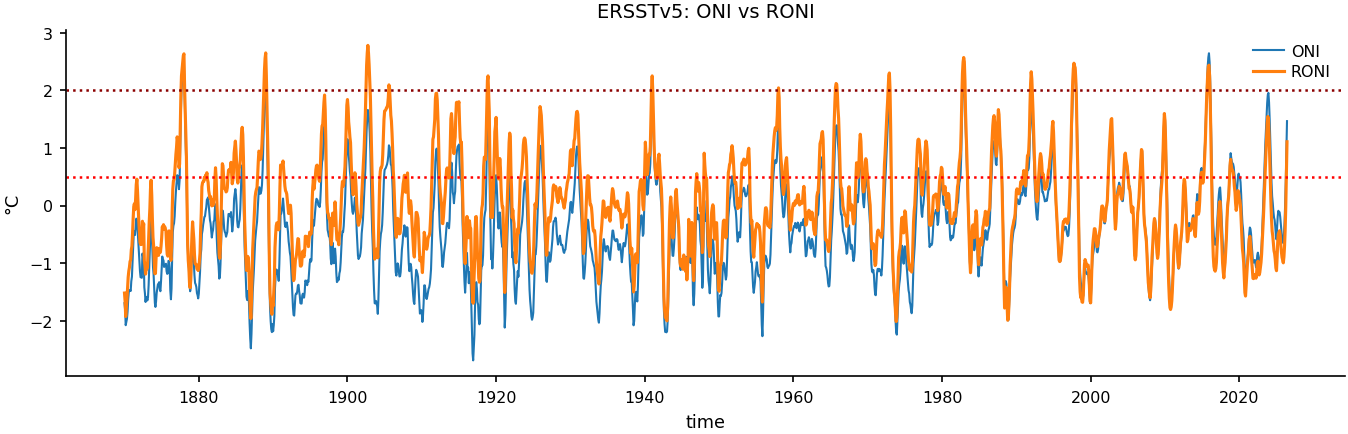

In [13]:
name = "ERSSTv5"
fig, ax = plt.subplots(figsize=(11, 3))
oni[name].sel(time=slice("1870", None)).plot(ax=ax, label="ONI", lw=1)
roni[name].sel(time=slice("1870", None)).plot(ax=ax, label="RONI", lw=1.5)
ax.axhline(0.5, color="r", ls=":"); ax.axhline(2.0, color="darkred", ls=":")
ax.set_title(f"{name}: ONI vs RONI"); ax.set_ylabel("°C"); ax.legend(); plt.show()

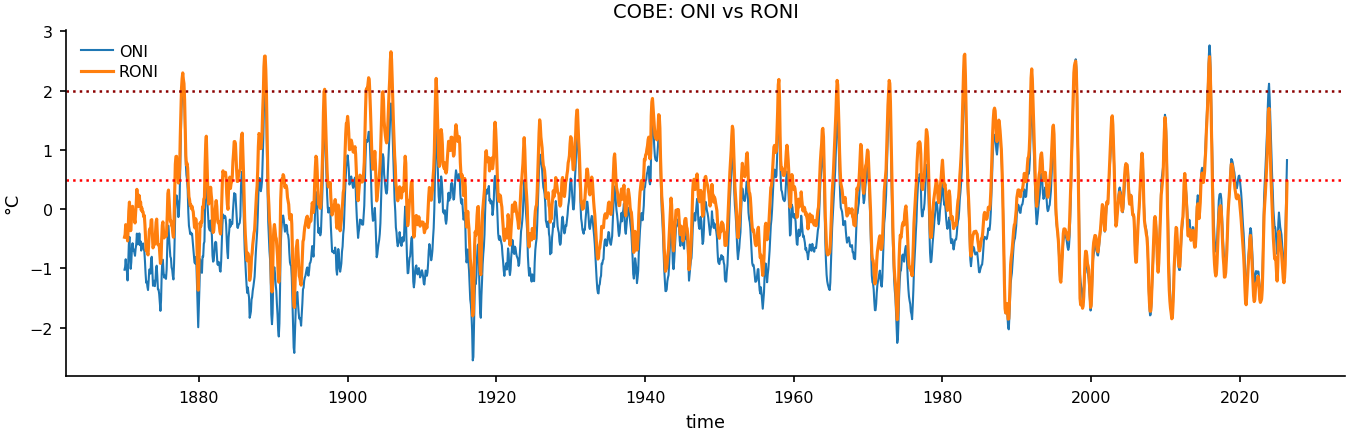

In [14]:
name = "COBE"
fig, ax = plt.subplots(figsize=(11, 3))
oni[name].sel(time=slice("1870", None)).plot(ax=ax, label="ONI", lw=1)
roni[name].sel(time=slice("1870", None)).plot(ax=ax, label="RONI", lw=1.5)
ax.axhline(0.5, color="r", ls=":"); ax.axhline(2.0, color="darkred", ls=":")
ax.set_title(f"{name}: ONI vs RONI"); ax.set_ylabel("°C"); ax.legend(); plt.show()

In [15]:
import pandas as pd

def detect_events(roni_series, threshold=0.5, min_len=5):
    """El Niño events: RONI >= threshold for >= min_len consecutive months
    (= 5 overlapping 3-month seasons). Returns peak magnitude per event."""
    r = roni_series.dropna("time")
    vals, times = r.values, r.time.values
    above = vals >= threshold
    events, i, n = [], 0, len(vals)
    while i < n:
        if above[i]:
            j = i
            while j < n and above[j]:
                j += 1
            if (j - i) >= min_len:
                k = i + int(np.argmax(vals[i:j]))
                events.append(dict(
                    start=pd.Timestamp(times[i]),
                    end=pd.Timestamp(times[j-1]),
                    peak_time=pd.Timestamp(times[k]),
                    peak=float(vals[k]),
                    duration=int(j-i)))
            i = j
        else:
            i += 1
    return events

events = {name: detect_events(roni[name]) for name in roni}

for name in events:
    df = pd.DataFrame(events[name])
    print(f"\n===== {name}: {len(df)} El Niño events =====")
    print(df.assign(
        peak_season=df.peak_time.dt.strftime("%Y-%m"),
        start=df.start.dt.strftime("%Y-%m"),
        end=df.end.dt.strftime("%Y-%m")
    )[["start","end","peak_season","peak","duration"]].to_string(index=False))


===== COBE: 43 El Niño events =====
  start     end peak_season     peak  duration
1855-10 1856-03     1855-12 1.350801         6
1864-09 1865-03     1865-02 1.044911         7
1867-10 1868-02     1868-01 0.966630         5
1868-10 1869-02     1868-11 1.356188         5
1876-11 1877-03     1877-01 0.893121         5
1877-05 1878-07     1877-11 2.300956        15
1883-04 1883-09     1883-04 0.648464         6
1884-07 1885-02     1884-11 1.142615         8
1885-05 1886-01     1885-11 1.284626         9
1887-12 1889-04     1888-12 2.585161        17
1896-08 1897-04     1896-12 2.024706         9
1899-08 1901-03     1900-01 1.567175        20
1902-03 1903-10     1902-11 2.219578        20
1904-04 1906-06     1905-11 2.657814        27
1911-07 1915-06     1911-12 2.207976        48
1918-07 1920-02     1919-11 1.468608        20
1923-07 1923-12     1923-10 1.208083         6
1925-08 1926-08     1925-11 1.509079        13
1929-07 1931-04     1930-12 1.674104        22
1935-10 1936-02     193

In [16]:
# label each event by the calendar year of its peak, rank by peak RONI within each product
rank_tables = {}
for name in events:
    df = pd.DataFrame(events[name])
    df["label"] = df.peak_time.dt.year.astype(str)
    df["rank"]  = df["peak"].rank(ascending=False).astype(int)
    rank_tables[name] = df.sort_values("peak", ascending=False)

# cross-product view of the biggest historical events
print("Top 8 events by peak RONI, each product:\n")
for name in rank_tables:
    top = rank_tables[name].head(8)
    line = "  ".join(f"{r.label}:{r.peak:.2f}" for _, r in top.iterrows())
    print(f"{name:8s}  {line}")

Top 8 events by peak RONI, each product:

COBE      1905:2.66  1983:2.62  1888:2.59  2015:2.58  1997:2.50  1992:2.37  1877:2.30  1902:2.22
DCSST     1982:2.82  1877:2.66  2015:2.57  1888:2.52  1997:2.46  1902:2.31  1992:2.28  1972:2.26
HadISST   1878:2.71  1982:2.61  1888:2.44  2015:2.34  1997:2.26  1972:2.20  1902:2.17  1992:2.05
HadSST4   1914:3.34  1919:3.20  1941:3.05  1982:3.01  2015:2.66  1889:2.57  1997:2.50  1992:2.41
ERSSTv5   1902:2.78  1889:2.65  1878:2.63  1982:2.57  1997:2.47  2015:2.44  1992:2.32  1972:2.30


In [17]:
# valid (non-NaN) monthly RONI per product → intersection of covered months
valid = {name: roni[name].dropna("time") for name in roni}
starts = {name: pd.Timestamp(v.time.values[0])  for name, v in valid.items()}
ends   = {name: pd.Timestamp(v.time.values[-1]) for name, v in valid.items()}

common_start = max(starts.values())
common_end   = min(ends.values())
print("per-product coverage:")
for name in roni:
    print(f"  {name:8s} {starts[name].date()} → {ends[name].date()}")
print(f"\nlongest COMMON obs window: {common_start.date()} → {common_end.date()}")

per-product coverage:
  COBE     1850-02-01 → 2026-05-01
  DCSST    1850-02-14 → 2024-11-15
  HadISST  1870-02-14 → 2026-04-16
  HadSST4  1850-02-15 → 2026-05-15
  ERSSTv5  1854-02-01 → 2026-06-01

longest COMMON obs window: 1870-02-14 → 2024-11-15


In [18]:
def enso_winter_year(ts):
    """Assign an event to its boreal-winter year (Dec-centered)."""
    return ts.year if ts.month >= 7 else ts.year - 1

prods = list(events)
records = []
for name in prods:
    for e in events[name]:
        records.append(dict(product=name, year=enso_winter_year(e["peak_time"]),
                            peak=e["peak"], duration=e["duration"]))
alldf = pd.DataFrame(records)

infilled = ["COBE", "DCSST", "HadISST", "ERSSTv5"]   # share reconstruction assumptions
check    = "HadSST4"                                  # infill-free independent check

mat = alldf.pivot_table(index="year", columns="product", values="peak", aggfunc="max")
mat["mean"]  = mat[infilled].mean(axis=1)
mat["min"]   = mat[infilled].min(axis=1)
mat["max"]   = mat[infilled].max(axis=1)
mat["nprod"] = mat[infilled].notna().sum(axis=1)      # infilled-product coverage

reliable = mat[(mat.index >= 1870) & (mat.index <=2026) & (mat["nprod"] >= 3)].sort_values("mean", ascending=False)
print(reliable[["mean","min","max","nprod",check]].head(12).round(2).to_string())

product  mean   min   max  nprod  HadSST4
year                                     
1982     2.65  2.57  2.82      4     3.01
1877     2.58  2.30  2.71      4     1.95
1888     2.55  2.44  2.65      4     2.57
2015     2.48  2.34  2.58      4     2.66
1997     2.42  2.26  2.50      4     2.50
1902     2.37  2.17  2.78      4     2.20
1991     2.26  2.05  2.37      4     2.41
1972     2.23  2.17  2.30      4     2.28
1905     2.13  1.87  2.66      4      NaN
1965     2.10  2.05  2.17      4     2.20
1918     2.01  1.85  2.25      3     3.20
1911     1.97  1.75  2.21      4     1.94


##  ingest forecast data (CPC data ENSMEAN)

In [19]:
# RUN THIS PRIOR in terminal for forecast
# CYCLE=2026080800
# YM=${CYCLE:0:6}
# DEST=/g/data/if69/as8561/data/nmme_$CYCLE
# mkdir -p "$DEST" && cd "$DEST"
# base=https://ftp.cpc.ncep.noaa.gov/NMME/realtime_anom/ENSMEAN/$CYCLE
# for m in NMME CFSv2 CanESM5 GEM5.2_NEMO NASA_GEOS5v2 NCAR_CCSM4 NCAR_CESM1 GFDL_SPEAR; do
#   wget -nc "$base/$m.tmpsfc.$YM.ENSMEAN.anom.nc"
# done
# ls -lh



In [20]:


# import glob, os

# # ============ CONFIG — bump this when a new forecast cycle lands ============
# CYCLE    = "2026080800"                          # try July; use 2026060800 if not up yet
# NMME_DIR = f"/g/data/if69/as8561/data/nmme_{CYCLE}"   # wherever you wget'd the files
# # ==========================================================================

# nmme_files = sorted(glob.glob(os.path.join(NMME_DIR, "*.tmpsfc.*.ENSMEAN.anom.nc")))
# print(f"{len(nmme_files)} files in {NMME_DIR}:")
# for f in nmme_files: print("  ", os.path.basename(f))

# ds = xr.open_dataset(nmme_files[0], decode_times=False)
# print("\ndata vars :", list(ds.data_vars))
# print("coords    :", list(ds.coords))
# print("dims      :", dict(ds.sizes))
# for c in ds.coords:
#     v = ds[c]
#     print(f"  {c:10s} units={v.attrs.get('units','')!r:35s} "
#           f"vals[0:3]={np.ravel(v.values)[:3]} ... [-1]={np.ravel(v.values)[-1]}")
# ds.close()

In [21]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:       (lon: 360, lat: 181, target: 9, initial_time: 1)
Coordinates:
  * lon           (lon) float32 1kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * lat           (lat) float32 724B 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * target        (target) float32 36B 799.0 800.0 801.0 ... 805.0 806.0 807.0
  * initial_time  (initial_time) float32 4B 799.0
Data variables:
    fcst          (target, lat, lon) float32 2MB ...
Attributes:
    creation_date:  Fri Aug  7 19:20:11 2026

In [22]:
# RONI variance scale — identical definition to the observed RONI (Cell 5),
# so the forecast lands on the same axis as the Figure-1 ranking.
def _obs_scale(name):
    n34a = funcs.calc_anom(n34_sst[name],  n34_sst[name].sel(time=BASE))
    trpa = funcs.calc_anom(trop_sst[name], trop_sst[name].sel(time=BASE))
    return float(three_month(n34a).std()) / float(three_month(n34a - trpa).std())
SCALE = float(np.median([_obs_scale(n) for n in infilled]))     # set to 1.0 for Miami (unscaled) convention
print(f"RONI scale applied: {SCALE:.3f}")


def _decode_target(ds, tname):
    """Turn a 'months since REF' lead axis into a monthly DatetimeIndex."""
    units = ds[tname].attrs.get("units", "")
    vals = np.asarray(ds[tname].values, dtype=float)
    if "months since" in units:
        ref = pd.Timestamp(units.split("since")[1].strip())
        base = ref.year * 12 + (ref.month - 1)
        idx = base + np.floor(vals).astype(int)          # .5 = mid-month marker → floor
        years, months = idx // 12, idx % 12 + 1
        return pd.to_datetime([f"{y}-{m:02d}-01" for y, m in zip(years, months)])
    # already decodable units → let xarray handle it
    return pd.to_datetime(xr.decode_cf(ds[[tname]])[tname].values)

def load_nmme_sst(path):
    """Clean SST-anomaly DataArray (time, lat, lon), lon 0–360, lat ascending."""
    ds = xr.open_dataset(path, decode_times=False)
    varname = max(ds.data_vars, key=lambda v: ds[v].ndim)
    da = ds[varname]

    ren = {}
    for c in da.dims:
        cl = c.lower()
        if cl in ("latitude", "lat", "y"):   ren[c] = "lat"
        elif cl in ("longitude", "lon", "x"): ren[c] = "lon"
    da = da.rename(ren)

    nonspatial = [c for c in da.dims if c not in ("lat", "lon")]
    for c in list(nonspatial):
        if da.sizes[c] == 1: da = da.squeeze(c, drop=True)
    nonspatial = [c for c in da.dims if c not in ("lat", "lon")]
    if nonspatial:
        tname = max(nonspatial, key=lambda c: da.sizes[c])
        da = da.assign_coords({tname: _decode_target(ds, tname)})
        if tname != "time": da = da.rename({tname: "time"})

    da = da.assign_coords(lon=(da.lon % 360)).sortby("lon").sortby("lat")
    da = da.where((da > -50) & (da < 50))
    # drop forecast leads that are entirely zero/NaN (unfilled months)
    nonzero = (da.fillna(0) != 0).any(dim=[d for d in da.dims if d != "time"])
    da = da.sel(time=da.time[nonzero.values])
    return da


def forecast_roni(path):
    da  = load_nmme_sst(path)                                    # (has the zero-lead drop patch)
    n34 = area_mean(da, -5, 5, 190, 240).compute()
    trp = area_mean(da, -20, 20, 0, 360).compute()
    return (three_month(n34 - trp) * SCALE)

fc_files = sorted(glob.glob(os.path.join(NMME_DIR, "*.tmpsfc.*.ENSMEAN.anom.nc")))
roni_fc  = {os.path.basename(f).split(".tmpsfc")[0]: forecast_roni(f) for f in fc_files}

rows = []
for m, r in roni_fc.items():
    r = r.dropna("time"); k = int(r.argmax())
    rows.append(dict(model=m, peak=round(float(r[k]), 2), at=str(r.time.values[k])[:7]))
fc_tbl = pd.DataFrame(rows).sort_values("peak", ascending=False)
print("\nforecast RONI (scaled), init", CYCLE, ":\n", fc_tbl.to_string(index=False))

# central estimate = NMME multi-model file; spread = across the 6 model means
members = [m for m in roni_fc if m.upper() != "NMME"]
f2026 = dict(
    best = round(float(roni_fc["NMME"].max()), 2) if "NMME" in roni_fc
           else round(float(np.mean([roni_fc[m].max() for m in members])), 2),
    low  = round(float(np.min([roni_fc[m].max() for m in members])), 2),
    high = round(float(np.max([roni_fc[m].max() for m in members])), 2),
    cycle = CYCLE, scaled = True, models = len(members),
)
print("\nf2026:", f2026)

RONI scale applied: 1.241

forecast RONI (scaled), init 2026080800 :
        model  peak      at
NASA_GEOS5v2  4.51 2027-02
  NCAR_CESM1  4.40 2026-11
 GEM5.2_NEMO  3.93 2026-11
       CFSv2  3.56 2026-10
        NMME  3.54 2026-11
  NCAR_CCSM4  3.09 2026-10
     CanESM5  2.65 2026-12

f2026: {'best': 3.54, 'low': 2.65, 'high': 4.51, 'cycle': '2026080800', 'scaled': True, 'models': 6}


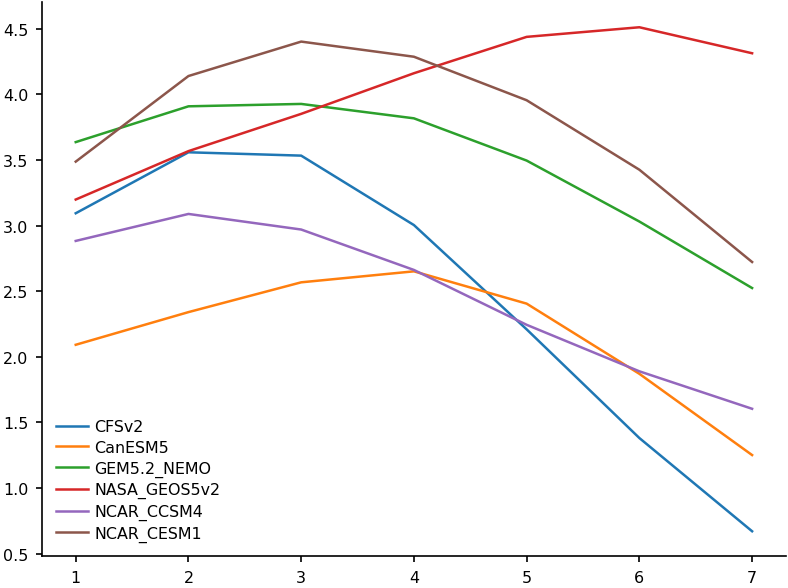

In [23]:
for i in range(len(members)):
    plt.plot(roni_fc[members[i]], label=f'{members[i]}')
plt.legend()

In [24]:
# raw components for the multi-model file (before the RONI scale)
da = load_nmme_sst([f for f in nmme_files if "NMME.tmpsfc" in f][0])
n34 = area_mean(da, -5, 5, 190, 240).compute()
trp = area_mean(da, -20, 20, 0, 360).compute()
rel = (n34 - trp)
diag = pd.DataFrame({
    "Niño3.4 anom": n34.values.round(2),
    "trop mean anom": trp.values.round(2),
    "relative (N34−trop)": rel.values.round(2),
    "×scale (RONI)": (rel.values * SCALE).round(2),
}, index=[str(t)[:7] for t in n34.time.values])
print("NMME raw forecast decomposition:\n", diag, "\n")

# where does OBSERVED RONI actually stand right now?
print("latest observed RONI (already in hand):")
for name in ["COBE", "HadISST", "HadSST4"]:      # the three that reach 2026
    r = roni[name].dropna("time")
    tail = r.sel(time=slice("2025-06", None))
    print(f"  {name:8s}", "  ".join(f"{str(t)[:7]}:{float(v):.2f}"
          for t, v in zip(tail.time.values, tail.values)))

NMME raw forecast decomposition:
          Niño3.4 anom  trop mean anom  relative (N34−trop)  ×scale (RONI)
2026-08          2.76            0.73                 2.03           2.52
2026-09          3.33            0.80                 2.53           3.15
2026-10          3.73            0.91                 2.82           3.50
2026-11          3.94            1.00                 2.94           3.65
2026-12          3.85            1.05                 2.80           3.48
2027-01          3.63            1.08                 2.55           3.16
2027-02          3.27            1.09                 2.18           2.71
2027-03          2.77            1.05                 1.72           2.13
2027-04          2.31            0.99                 1.32           1.64 

latest observed RONI (already in hand):
  COBE     2025-06:-0.56  2025-07:-0.64  2025-08:-0.72  2025-09:-0.88  2025-10:-1.04  2025-11:-1.18  2025-12:-1.24  2026-01:-1.15  2026-02:-0.94  2026-03:-0.50  2026-04:-0.05  2026-05:

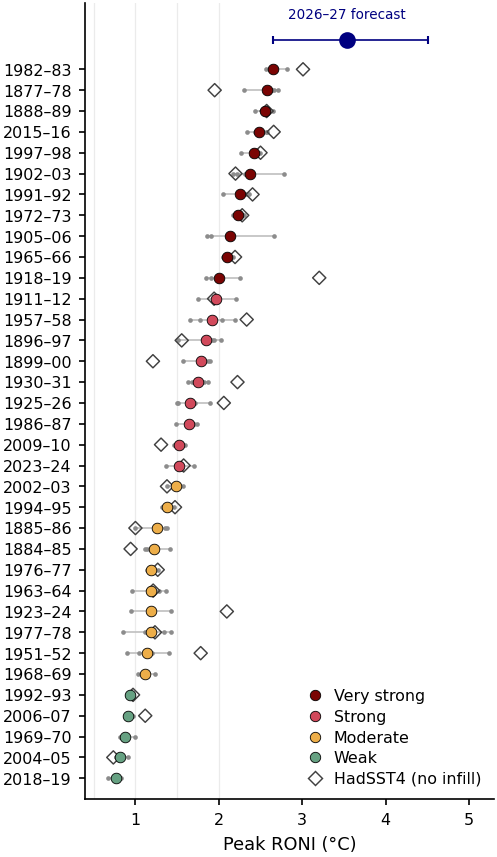

In [25]:
era = mat[(mat.index >= 1870) & (mat.index <= 2026) & (mat["nprod"] >= 3)].sort_values("mean")
y = np.arange(len(era))
cats = [(2.0,"#7a0403","Very strong"),(1.5,"#d1495b","Strong"),
        (1.0,"#edae49","Moderate"),(0.0,"#66a182","Weak")]
def cat_color(v): return next(c for t,c,_ in cats if v>=t)

fig, ax = plt.subplots(figsize=(SINGLE_COL, 150*MM))
for i,(yr,row) in zip(y, era.iterrows()):
    ax.plot([row["min"],row["max"]],[i,i], color="0.75", lw=0.8, zorder=1)          # infilled spread
    ax.scatter(row[infilled],[i]*len(infilled), s=5, color="0.55", lw=0, zorder=2)  # infilled members
    ax.scatter(row["mean"], i, s=26, color=cat_color(row["mean"]),
               edgecolor="k", lw=0.4, zorder=3)                                     # infilled mean
    if np.isfinite(row[check]):                                                     # HadSST4 = open diamond
        ax.scatter(row[check], i, s=20, marker="D", facecolor="none",
                   edgecolor="0.25", lw=0.7, zorder=2.5)
ax.set_yticks(y); ax.set_yticklabels([f"{yr}\u2013{str(yr+1)[-2:]}" for yr in era.index])

# f2026 = dict(best=2.6, low=2.2, high=3.0)   # placeholder until forecast ingest
ax.errorbar(f2026["best"], len(era)+0.4,
            xerr=[[f2026["best"]-f2026["low"]],[f2026["high"]-f2026["best"]]],
            fmt="o", ms=7, color="navy", mec="navy", capsize=2, lw=0.8, zorder=4)
ax.text(f2026["best"], len(era)+1.3, "2026\u201327 forecast", ha="center",
        va="bottom", color="navy", fontsize=6.5)

for x in (0.5,1.0,1.5,2.0): ax.axvline(x, color="0.92", lw=0.6, zorder=0)
ax.set_xlim(0.4,5.3); ax.set_ylim(-1, len(era)+2.2)
ax.set_xlabel("Peak RONI (\u00b0C)")

from matplotlib.lines import Line2D
leg = [Line2D([0],[0], marker="o", ls="", mfc=c, mec="k", mew=0.4, ms=5, label=l)
       for _,c,l in cats]
leg += [Line2D([0],[0], marker="D", ls="", mfc="none", mec="0.25", mew=0.7, ms=5,
               label="HadSST4 (no infill)")]
ax.legend(handles=leg, loc="lower right", frameon=False, handletextpad=0.2, borderpad=0.3)
# ax.set_title("Observed El Ni\u00f1o peak magnitude, 1950\u2013present")
plt.tight_layout()
# fig.savefig("fig1_obs_ranking.pdf")
# plt.show()

## CCSR columbia ingest

In [42]:
CCSR = "https://forecast.ccsr.columbia.edu/data/NMME"
models = {
    "GEOSS2S":     f"{CCSR}/NASA-GMAO/GEOSS2S",
    "CanSIPS-IC4": f"{CCSR}/ECCC/CanSIPS-IC4",
    "CCSM4":       f"{CCSR}/COLA-RSMAS/CCSM4",
    "CESM1":       f"{CCSR}/COLA-RSMAS/CESM1",
    "SPEAR":       f"{CCSR}/NOAA-GFDL/SPEAR",
}

# --- connectivity + subset test on one model ---
url = f"{models['GEOSS2S']}/forecast/tos"
ds  = xr.open_dataset(url)                 # OPeNDAP DAP2; lazy, no bulk download
print("dims:", dict(ds.sizes))
print("last starts:", ds.S.values[-4:])
print("units:", ds.tos.attrs.get("units"))

# pull ONLY the Niño-3.4 box for the 2026-87 start, all members → area-mean
box = ds.tos.sel(S="2026-08-01", Y=slice(-5, 5), X=slice(190, 240))
w   = np.cos(np.deg2rad(box.Y))
n34 = box.weighted(w).mean(("Y", "X")).mean("M").compute()   # raw SST by lead
print("\nGEOSS2S raw Niño3.4 SST by lead (2026-08 init):")
print(np.round(n34.values, 2))

dims: {'S': 115, 'L': 9, 'M': 10, 'Y': 181, 'X': 360, 'nbound': 2}
last starts: ['2026-05-01T00:00:00.000000000' '2026-06-01T00:00:00.000000000'
 '2026-07-01T00:00:00.000000000' '2026-08-01T00:00:00.000000000']
units: degree_Celsius

GEOSS2S raw Niño3.4 SST by lead (2026-08 init):
[29.55 29.56 30.08 30.58 30.84 30.97 31.09 31.16 31.42]


In [43]:
# obs Niño3.4 σ by calendar month, 1982–2010 (CPC's amplitude-correction reference)
obs_n34a = funcs.calc_anom(n34_sst["ERSSTv5"], n34_sst["ERSSTv5"].sel(time=BASE))
obs_sigma_mon = obs_n34a.sel(time=slice("1982", "2010")).groupby("time.month").std()
SCALE = float(np.median([_obs_scale(n) for n in infilled]))    # RONI variance scale (~1.24)


def _amean(da, y0, y1, x0=0, x1=360, stride=1):
    b = da.sel(Y=slice(y0, y1), X=slice(x0, x1))
    if stride > 1:
        b = b.isel(Y=slice(None, None, stride), X=slice(None, None, stride))
    b = b.where((b > -5) & (b < 45))                 # mask land/ice fill → NaN
    w = np.cos(np.deg2rad(b.Y))
    return b.weighted(w).mean(("Y", "X"), skipna=True)

def _n34(da):  return _amean(da, -5, 5, 190, 240)
def _trop(da): return _amean(da, -20, 20, 0, 360, stride=3)

from tqdm.auto import tqdm
import time

def open_model(name):
    """Return (forecast_ds, hindcast_ds); some models split them, others use one unified sst."""
    base = models[name]
    try:
        return xr.open_dataset(f"{base}/forecast/tos"), xr.open_dataset(f"{base}/hindcast/tos")
    except OSError:
        ds = xr.open_dataset(f"{base}/tos")          # unified: contains all starts
        return ds, ds


from concurrent.futures import ThreadPoolExecutor, TimeoutError as FTimeout
_pool = ThreadPoolExecutor(max_workers=8)

def _fetch(da, timeout=120, tries=4):
    for i in range(tries):
        try:
            return _pool.submit(da.compute).result(timeout=timeout)
        except FTimeout:
            print(f"    stalled >{timeout}s, retry {i+1}")
        except Exception as e:
            if i == tries - 1: raise
            print(f"    {type(e).__name__}, retry {i+1}"); time.sleep(2)
    raise RuntimeError("fetch failed")


def _log(msg):
    print(f"    [{time.strftime('%H:%M:%S')}] {msg}", flush=True)



def _fetch_hc(regionfn, hc, starts, label, ensmean=True):
    outs = []
    for i, s in enumerate(starts, 1):
        if i == 1 or i % 10 == 0 or i == len(starts):
            _log(f"{label}: hindcast {i}/{len(starts)} ...")
        r = _fetch(regionfn(hc.tos.sel(S=s)))
        outs.append(r.mean("M") if ensmean else r)          # keep members when ensmean=False
    return xr.concat(outs, dim="S")




def process_model(name):
    _log(f"opening {name} ...")
    fc, hc = open_model(name)
    if np.datetime64("2026-08-01") not in fc.S.values:
        raise ValueError("no 2026-08-01 start")
    fcS = fc.tos.sel(S="2026-08-01")
    _log("forecast: Niño3.4 ...");  fc_n34_mem = _fetch(_n34(fcS))      # (M,L) keep members
    fc_n34 = fc_n34_mem.mean("M")                                       # ensemble mean
    _log("forecast: tropics ...");  fc_trp = _fetch(_trop(fcS)).mean("M")

    yr, mo = hc.S.dt.year.values, hc.S.dt.month.values
    starts = hc.S.values[(mo == 7) & (yr >= 1991) & (yr <= 2020)]
    _log(f"{len(starts)} hindcast starts")
    hc_n34 = _fetch_hc(_n34, hc, starts, "Niño3.4", ensmean=False)      # (S,M,L) keep members
    hc_trp = _fetch_hc(_trop, hc, starts, "tropics", ensmean=True)      # (S,L)

    _log("computing RONI + amplitude correction ...")
    clim_n34 = hc_n34.mean(("S", "M"))
    clim_trp = hc_trp.mean("S")
    fc_n34a  = fc_n34 - clim_n34;  fc_trpa = fc_trp - clim_trp
    sig_h    = (hc_n34 - clim_n34).std("S").mean("M")                   # per-member σ (count-independent)

    tmon  = fcS.target.dt.month.values
    sig_o = xr.DataArray([float(obs_sigma_mon.sel(month=m)) for m in tmon],
                         dims="L", coords={"L": fc_n34.L})
    factor = (sig_h / sig_o).where(np.isfinite(sig_h / sig_o) & (sig_h > 0), 1.0).clip(0.5, 3.5)

    roni_raw  = (fc_n34a          - fc_trpa).rolling(L=3, center=True, min_periods=2).mean() * SCALE
    roni_corr = (fc_n34a / factor - fc_trpa).rolling(L=3, center=True, min_periods=2).mean() * SCALE

    fc_n34a_mem  = fc_n34_mem - clim_n34                                # (M,L) per-member anomaly
    roni_mem_raw = (fc_n34a_mem          - fc_trpa).rolling(L=3, center=True, min_periods=2).mean() * SCALE
    roni_mem_cor = (fc_n34a_mem / factor - fc_trpa).rolling(L=3, center=True, min_periods=2).mean() * SCALE

    return dict(name=name, factor=factor.values, roni_raw=roni_raw, roni_corr=roni_corr, roni_mem_cor=roni_mem_cor,
                member_peaks_corr=roni_mem_cor.max("L").values,
                member_peaks_raw =roni_mem_raw.max("L").values)

In [29]:
# # --- validate on GEOSS2S ---
# r = process_model("GEOSS2S")
# print("amplitude factor by lead:", np.round(r["factor"], 2))
# print("target months        :", r["tmon"])
# print(f"\nGEOSS2S ensemble-mean RONI  raw peak = {float(r['mean_raw'].max()):.2f}"
#       f"   corrected peak = {float(r['mean_corr'].max()):.2f}")
# print("member-spread corrected peak: "
#       f"[{float(r['roni_corr'].max('L').min()):.2f}, {float(r['roni_corr'].max('L').max()):.2f}]")


In [44]:
# --- loop ---
results = {}
for m in tqdm(models, desc="NMME models"):
    print(f"\n=== now processing: {m} ===", flush=True)
    try:
        results[m] = process_model(m)
        print(f"=== done {m}: raw {float(results[m]['roni_raw'].max()):.2f} "
              f"→ corr {float(results[m]['roni_corr'].max()):.2f} ===", flush=True)
    except Exception as e:
        print(f"=== SKIPPED {m}: {type(e).__name__}: {e} ===", flush=True)

NMME models:   0%|          | 0/5 [00:00<?, ?it/s]


=== now processing: GEOSS2S ===
    [17:02:12] opening GEOSS2S ...
    [17:02:16] forecast: Niño3.4 ...
    [17:02:17] forecast: tropics ...
    [17:02:17] 26 hindcast starts
    [17:02:17] Niño3.4: hindcast 1/26 ...
    [17:02:21] Niño3.4: hindcast 10/26 ...
    [17:02:24] Niño3.4: hindcast 20/26 ...
    [17:02:26] Niño3.4: hindcast 26/26 ...
    [17:02:27] tropics: hindcast 1/26 ...
    [17:02:30] tropics: hindcast 10/26 ...
    [17:02:33] tropics: hindcast 20/26 ...
    [17:02:35] tropics: hindcast 26/26 ...
    [17:02:36] computing RONI + amplitude correction ...
=== done GEOSS2S: raw 3.94 → corr 2.22 ===

=== now processing: CanSIPS-IC4 ===
    [17:02:36] opening CanSIPS-IC4 ...
    [17:02:40] forecast: Niño3.4 ...
    [17:02:49] forecast: tropics ...
    [17:03:05] 30 hindcast starts
    [17:03:05] Niño3.4: hindcast 1/30 ...
    [17:04:05] Niño3.4: hindcast 10/30 ...
    [17:05:06] Niño3.4: hindcast 20/30 ...
    [17:05:42] Niño3.4: hindcast 30/30 ...
    [17:05:48] tropics: hin

syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: <html^> <head> <title>404 Not Found</title> </head> <body> <h1>404 Not Found</h1> The resource could not be found.<br /><br /> </body></html>


    [17:09:49] forecast: Niño3.4 ...
    [17:09:51] forecast: tropics ...
    [17:09:52] 30 hindcast starts
    [17:09:52] Niño3.4: hindcast 1/30 ...
    [17:10:04] Niño3.4: hindcast 10/30 ...
    [17:10:16] Niño3.4: hindcast 20/30 ...
    [17:10:29] Niño3.4: hindcast 30/30 ...
    [17:10:30] tropics: hindcast 1/30 ...
    [17:10:41] tropics: hindcast 10/30 ...
    [17:10:54] tropics: hindcast 20/30 ...
    [17:11:07] tropics: hindcast 30/30 ...
    [17:11:08] computing RONI + amplitude correction ...
=== done CCSM4: raw 3.10 → corr 2.96 ===

=== now processing: CESM1 ===
    [17:11:08] opening CESM1 ...


syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: <html^> <head> <title>404 Not Found</title> </head> <body> <h1>404 Not Found</h1> The resource could not be found.<br /><br /> </body></html>


    [17:11:12] forecast: Niño3.4 ...
    [17:11:14] forecast: tropics ...
    [17:11:15] 30 hindcast starts
    [17:11:15] Niño3.4: hindcast 1/30 ...
    [17:11:27] Niño3.4: hindcast 10/30 ...
    [17:11:39] Niño3.4: hindcast 20/30 ...
    [17:11:52] Niño3.4: hindcast 30/30 ...
    [17:11:53] tropics: hindcast 1/30 ...
    [17:12:04] tropics: hindcast 10/30 ...
    [17:12:17] tropics: hindcast 20/30 ...
    [17:12:29] tropics: hindcast 30/30 ...
    [17:12:31] computing RONI + amplitude correction ...
=== done CESM1: raw 4.53 → corr 3.48 ===

=== now processing: SPEAR ===
    [17:12:31] opening SPEAR ...
=== SKIPPED SPEAR: ValueError: no 2026-08-01 start ===


In [45]:
Lmin    = min(r["roni_corr"].sizes["L"] for r in results.values())
mm_mean = sum(r["roni_corr"].isel(L=slice(0, Lmin)) for r in results.values()) / len(results)
model_peaks = {m: round(float(r["roni_corr"].max()), 2) for m, r in results.items()}
pk = np.array(list(model_peaks.values()))
f2026 = dict(best=round(float(mm_mean.max()), 2),
             low=round(float(pk.min()), 2), high=round(float(pk.max()), 2),
             cycle="2026-08", corrected=True, ensmean=True,
             per_model_corr=model_peaks,
             per_model_raw={m: round(float(r["roni_raw"].max()), 2) for m, r in results.items()})
print("\nf2026:", f2026)


f2026: {'best': 3.16, 'low': 2.22, 'high': 3.98, 'cycle': '2026-08', 'corrected': True, 'ensmean': True, 'per_model_corr': {'GEOSS2S': 2.22, 'CanSIPS-IC4': 3.98, 'CCSM4': 2.96, 'CESM1': 3.48}, 'per_model_raw': {'GEOSS2S': 3.94, 'CanSIPS-IC4': 3.1, 'CCSM4': 3.1, 'CESM1': 4.53}}


In [46]:
f2026

{'best': 3.16,
 'low': 2.22,
 'high': 3.98,
 'cycle': '2026-08',
 'corrected': True,
 'ensmean': True,
 'per_model_corr': {'GEOSS2S': 2.22,
  'CanSIPS-IC4': 3.98,
  'CCSM4': 2.96,
  'CESM1': 3.48},
 'per_model_raw': {'GEOSS2S': 3.94,
  'CanSIPS-IC4': 3.1,
  'CCSM4': 3.1,
  'CESM1': 4.53}}

In [47]:
# observed record = strongest reliably-observed event (1982-83); obs uncertainty = product spread
REC_YEAR = 1982
prod_rec       = {p: float(mat.loc[REC_YEAR, p]) for p in ["COBE","DCSST","HadISST","ERSSTv5"]}
thr_central    = float(np.mean(list(prod_rec.values())))
thr_lo, thr_hi = min(prod_rec.values()), max(prod_rec.values())
print(f"1982-83 record RONI: central {thr_central:.2f}  (product range {thr_lo:.2f}–{thr_hi:.2f})")
print("  per product:", {p: round(v, 2) for p, v in prod_rec.items()})

peaks_c = np.concatenate([r["member_peaks_corr"] for r in results.values()])
peaks_r = np.concatenate([r["member_peaks_raw"]  for r in results.values()])
Pc = lambda t: 100*np.mean(peaks_c > t)
Pr = lambda t: 100*np.mean(peaks_r > t)

print(f"\nAmplitude-corrected  ({peaks_c.size} members, median peak {np.median(peaks_c):.2f}):")
print(f"  P(exceed record) = {Pc(thr_central):.0f}%   (range {Pc(thr_hi):.0f}–{Pc(thr_lo):.0f}% over obs uncertainty)")
print(f"Raw (no ampl. corr.) for comparison: {Pr(thr_central):.0f}%")

1982-83 record RONI: central 2.65  (product range 2.57–2.82)
  per product: {'COBE': 2.62, 'DCSST': 2.82, 'HadISST': 2.61, 'ERSSTv5': 2.57}

Amplitude-corrected  (70 members, median peak 3.57):
  P(exceed record) = 84%   (range 81–87% over obs uncertainty)
Raw (no ampl. corr.) for comparison: 94%


In [48]:
f2026.update(dict(
    obs_record_central   = round(thr_central, 2),
    obs_record_range     = [round(thr_lo, 2), round(thr_hi, 2)],
    prob_exceed_record_pct       = round(100*np.mean(peaks_c > thr_central), 1),
    prob_exceed_record_range_pct = [round(100*np.mean(peaks_c > thr_hi), 1),
                                    round(100*np.mean(peaks_c > thr_lo), 1)],
    prob_exceed_raw_pct  = round(100*np.mean(peaks_r > thr_central), 1),
    n_members            = int(peaks_c.size),
    forecast_median_peak = round(float(np.median(peaks_c)), 2),
))

In [21]:
# save member-level trajectories, NaN-padded to 12 leads
def pad12(a):
    a = np.atleast_2d(np.asarray(a, float))            # (M, L)
    out = np.full((a.shape[0], 12), np.nan); out[:, :a.shape[1]] = a
    return out

# np.savez("/g/data/if69/as8561/data/f2026_roni_traj.npz",
#          **{f"{m}_mem": pad12(r["roni_mem_cor"].values) for m, r in results.items()},
#          **{f"{m}_ens": pad12(r["roni_corr"].values)    for m, r in results.items()},
#          models=np.array(list(results)))

In [50]:
# save
import json

DATA = "/g/data/if69/as8561/data"
with open(f"{DATA}/f2026_roni_forecast.json", "w") as fh:
    json.dump(f2026, fh, indent=2)
np.savez(f"{DATA}/f2026_roni_arrays.npz",
         mm_mean_traj=mm_mean.values, models=np.array(list(results)),
         member_peaks_corr=peaks_c, member_peaks_raw=peaks_r)

print("saved →", f"{DATA}/f2026_roni_forecast.json")
print(json.dumps(f2026, indent=2))

saved → /g/data/if69/as8561/data/f2026_roni_forecast.json
{
  "best": 3.16,
  "low": 2.22,
  "high": 3.98,
  "cycle": "2026-08",
  "corrected": true,
  "ensmean": true,
  "per_model_corr": {
    "GEOSS2S": 2.22,
    "CanSIPS-IC4": 3.98,
    "CCSM4": 2.96,
    "CESM1": 3.48
  },
  "per_model_raw": {
    "GEOSS2S": 3.94,
    "CanSIPS-IC4": 3.1,
    "CCSM4": 3.1,
    "CESM1": 4.53
  },
  "obs_record_central": 2.65,
  "obs_record_range": [
    2.57,
    2.82
  ],
  "prob_exceed_record_pct": 84.3,
  "prob_exceed_record_range_pct": [
    81.4,
    87.1
  ],
  "prob_exceed_raw_pct": 94.3,
  "n_members": 70,
  "forecast_median_peak": 3.57
}


In [22]:
import json
f2026 = json.load(open("/g/data/if69/as8561/data/f2026_roni_forecast.json"))

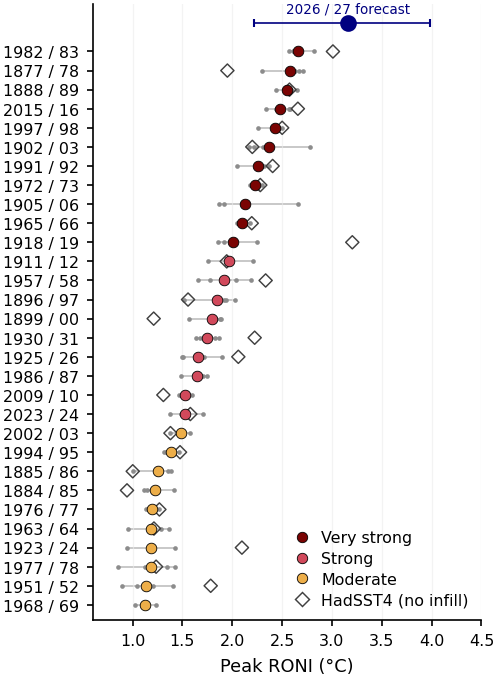

In [23]:
era = mat[(mat.index >= 1870) & (mat.index <= 2026) & (mat["nprod"] >= 3)]
era = era[era["mean"] >= 1.0].sort_values("mean")          # drop weak events
y = np.arange(len(era))
cats = [(2.0, "#7a0403", "Very strong"), (1.5, "#d1495b", "Strong"), (1.0, "#edae49", "Moderate")]
def cat_color(v): return next(c for t, c, _ in cats if v >= t)

fig, ax = plt.subplots(figsize=(SINGLE_COL, 120*MM))
for i, (yr, row) in zip(y, era.iterrows()):
    ax.plot([row["min"], row["max"]], [i, i], color="0.75", lw=0.8, zorder=1)
    ax.scatter(row[infilled], [i]*len(infilled), s=5, color="0.55", lw=0, zorder=2)
    ax.scatter(row["mean"], i, s=26, color=cat_color(row["mean"]),
               edgecolor="k", lw=0.4, zorder=3)
    if np.isfinite(row[check]):
        ax.scatter(row[check], i, s=20, marker="D", facecolor="none",
                   edgecolor="0.25", lw=0.7, zorder=2.5)
# ax.set_yticks(y); ax.set_yticklabels([f"{yr}\u2013{str(yr+1)[-2:]}" for yr in era.index])
ax.set_yticks(y); ax.set_yticklabels([f"{yr} / {str(yr+1)[-2:]}" for yr in era.index])

yf = len(era) + 0.5
ax.errorbar(f2026["best"], yf,
            xerr=[[f2026["best"]-f2026["low"]], [f2026["high"]-f2026["best"]]],
            fmt="o", ms=7, color="navy", mec="navy", capsize=2, lw=0.8, zorder=4)
ax.text(f2026["best"], yf + 0.35, "2026 / 27 forecast", ha="center",
        va="bottom", color="navy", fontsize=6.5)

# for x in (1.0, 1.5, 2.0, 3.0, 4.0): ax.axvline(x, color="0.92", lw=0.6, zorder=0)
plt.grid(axis='x', alpha=0.6, lw=0.6, color="0.92")
ax.set_xlim(0.6, 4.5)
ax.set_ylim(-0.8, yf + 1.0)                                 # stops just above the forecast label
ax.set_xlabel("Peak RONI (\u00b0C)")

from matplotlib.lines import Line2D
leg = [Line2D([0],[0], marker="o", ls="", mfc=c, mec="k", mew=0.4, ms=5, label=l)
       for _, c, l in cats]
leg += [Line2D([0],[0], marker="D", ls="", mfc="none", mec="0.25", mew=0.7, ms=5,
               label="HadSST4 (no infill)")]
ax.legend(handles=leg, loc="lower right", frameon=False, handletextpad=0.2, borderpad=0.3)
plt.tight_layout()

In [48]:
top = era.sort_values("mean", ascending=False).head(8)
print(f"{'event':10s} {'mean':>6s} {'min':>6s} {'max':>6s}   per-dataset")
for yr, row in top.iterrows():
    vals = "  ".join(f"{p}:{row[p]:.2f}" for p in infilled if np.isfinite(row[p]))
    print(f"  {yr}\u2013{str(yr+1)[-2:]} {row['mean']:6.2f} {row['min']:6.2f} "
          f"{row['max']:6.2f}   {vals}")

# consistency check against the thresholds used in the attribution
for y in events:
    print(f"  {y}: ranking {era.loc[y,'mean']:.2f}  vs  threshold {obs_thr['RONI'][y]:.2f}")

event        mean    min    max   per-dataset
  1982–83   2.65   2.57   2.82   COBE:2.62  DCSST:2.82  HadISST:2.61  ERSSTv5:2.57
  1877–78   2.58   2.30   2.71   COBE:2.30  DCSST:2.66  HadISST:2.71  ERSSTv5:2.63
  1888–89   2.55   2.44   2.65   COBE:2.59  DCSST:2.52  HadISST:2.44  ERSSTv5:2.65
  2015–16   2.48   2.34   2.58   COBE:2.58  DCSST:2.57  HadISST:2.34  ERSSTv5:2.44
  1997–98   2.42   2.26   2.50   COBE:2.50  DCSST:2.46  HadISST:2.26  ERSSTv5:2.47
  1902–03   2.37   2.17   2.78   COBE:2.22  DCSST:2.31  HadISST:2.17  ERSSTv5:2.78
  1991–92   2.26   2.05   2.37   COBE:2.37  DCSST:2.28  HadISST:2.05  ERSSTv5:2.32
  1972–73   2.23   2.17   2.30   COBE:2.17  DCSST:2.26  HadISST:2.20  ERSSTv5:2.30


KeyError: 'COBE'

## plume

In [24]:
import gzip
from pathlib import Path
from scipy.stats import skew

obs_dir = Path("/g/data/if69/as8561/data/obs_SST_products")
obs_files = {"COBE":"COBE_sst.mon.mean.nc", "DCSST":"DCSST-I_mean_1x1.nc",
             "HadISST":"HadISST_sst.nc.gz", "ERSSTv5":"ersst_v5.nc"}
BASE = slice("1991", "2020")

def open_obs(n):
    p = obs_dir / obs_files[n]
    if str(p).endswith(".gz"):
        with gzip.open(p) as f: return xr.open_dataset(f).load()
    return xr.open_dataset(p)

def obs_roni(n):
    ds = open_obs(n); v = "tos" if "tos" in ds.data_vars else "sst"
    da = ds[v]; ren = {}
    for c in da.coords:
        cl = c.lower()
        if cl in ("latitude","lat","y"):  ren[c] = "lat"
        if cl in ("longitude","lon","x"): ren[c] = "lon"
    da = da.rename(ren).squeeze(drop=True)
    da = da.assign_coords(lon=(da.lon % 360)).sortby("lon").sortby("lat")
    da = da.where((da > -5) & (da < 45))
    def am(d, y0, y1, x0=0, x1=360):
        b = d.sel(lat=slice(y0,y1), lon=slice(x0,x1))
        return b.weighted(np.cos(np.deg2rad(b.lat))).mean(("lat","lon"), skipna=True)
    n34, trp = am(da,-5,5,190,240), am(da,-20,20)
    a  = lambda s: (s.groupby("time.month") - s.sel(time=BASE).groupby("time.month").mean("time"))
    n34a, trpa = a(n34), a(trp)
    oni = n34a.rolling(time=3, center=True, min_periods=2).mean()
    rel = (n34a - trpa).rolling(time=3, center=True, min_periods=2).mean()
    return (rel * float(oni.std()) / float(rel.std())).compute()

roni_obs = {n: obs_roni(n) for n in obs_files}
OBS = "ERSSTv5"          # reference product for the plume

def traj(series, yr0):
    """Jul(yr0) → Jun(yr0+1) trajectory, 12 values."""
    s = series.sel(time=slice(f"{yr0}-07", f"{yr0+1}-06"))
    out = np.full(12, np.nan); out[:s.sizes["time"]] = s.values
    return out

MONTHS = ["Jul","Aug","Sep","Oct","Nov","Dec","Jan","Feb","Mar","Apr","May","Jun"]
print("obs RONI ready:", {n: f"{float(v.max()):.2f}" for n, v in roni_obs.items()})

obs RONI ready: {'COBE': '2.66', 'DCSST': '2.82', 'HadISST': '2.71', 'ERSSTv5': '2.78'}


observed: [-0.89 -0.7  -0.43 -0.02  0.52  1.11  1.4    nan   nan   nan   nan   nan
   nan   nan   nan   nan   nan   nan]
connector: Jul (+1.40) -> Aug (+2.44)


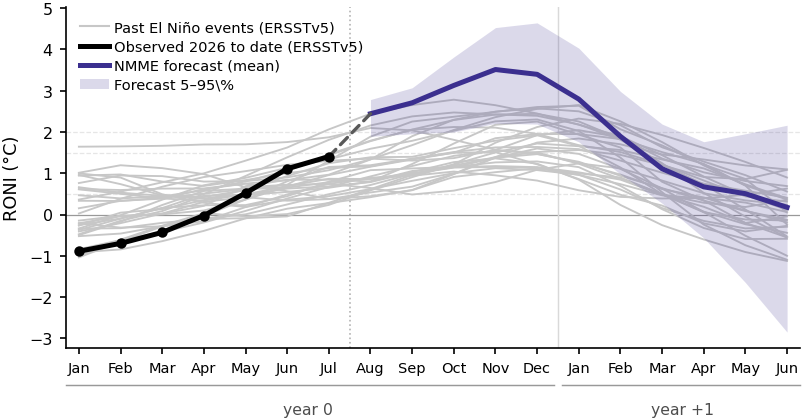

In [25]:
FC   = "#3b2f8f"
OBS  = "ERSSTv5"
past = era.index.tolist()

# ---- forecast cycle: change these two when a new cycle lands ----
INIT_YEAR, INIT_MONTH = 2026, 8          # August 2026 initialisation
EVENT_YEAR            = 2026             # ENSO year (Jul EVENT_YEAR -> Jun EVENT_YEAR+1)
OFF = (INIT_YEAR - EVENT_YEAR)*12 + (INIT_MONTH - 7)     # x position of first forecast lead

tr = np.load("/g/data/if69/as8561/data/f2026_roni_traj.npz", allow_pickle=True)
fmodels = list(tr["models"])

def traj18(series, yr):
    """Jan(yr) -> Jun(yr+1): 18 months, x = -6 .. 11 (x=0 is Jul of the event year)."""
    s = series.sel(time=slice(f"{yr}-01", f"{yr+1}-06"))
    out = np.full(18, np.nan)
    if s.sizes["time"]:
        i0 = (s.time.dt.year.values[0] - yr)*12 + (s.time.dt.month.values[0] - 1)
        out[i0:i0+s.sizes["time"]] = s.values
    return out

x = np.arange(-6, 12)
M18 = ["Jan","Feb","Mar","Apr","May","Jun"] + MONTHS

fig, ax = plt.subplots(figsize=(SINGLE_COL*1.8, 90*MM))
for yr in past:
    ax.plot(x, traj18(roni_obs[OBS], yr), color="0.78", lw=0.9, zorder=1)

# ---- forecast plume, positioned by initialisation month ----
key  = "_mem" if f"{fmodels[0]}_mem" in tr.files else "_corr"
mem  = np.vstack([pad12(tr[f"{m}{key}"]) for m in fmodels])
mean_t = np.nanmean(mem, 0); p05, p95 = np.nanpercentile(mem, [5, 95], 0)
xf = OFF + np.arange(mem.shape[1])
keep = xf <= x[-1]                                   # stay inside the axis
xf, mean_t, p05, p95 = xf[keep], mean_t[keep], p05[keep], p95[keep]

ax.fill_between(xf, p05, p95, color=FC, alpha=0.18, lw=0, zorder=3)
ax.plot(xf, mean_t, color=FC, lw=2.4, zorder=4)

# ---- observations to date ----
obs26 = traj18(roni_obs[OBS], EVENT_YEAR)
ax.plot(x, obs26, color="k", lw=2.4, zorder=5)
ax.plot(x, obs26, "o", ms=4, color="k", zorder=6)
print("observed:", np.round(obs26, 2))

# ---- dashed connector: last observation -> first forecast point ----
obs_ok, fc_ok = np.isfinite(obs26), np.isfinite(mean_t)
if obs_ok.any() and fc_ok.any():
    i_last, j_first = np.where(obs_ok)[0][-1], np.where(fc_ok)[0][0]
    x0, y0 = x[i_last],  obs26[i_last]
    x1, y1 = xf[j_first], mean_t[j_first]
    if x1 > x0:
        ax.plot([x0, x1], [y0, y1], color="0.35", lw=1.6,
                ls=(0, (3, 2)), dash_capstyle="round", zorder=4.5)
    print(f"connector: {M18[i_last]} ({y0:+.2f}) -> {M18[int(x1)+6]} ({y1:+.2f})")

ax.axvline(OFF - 0.5, color="0.7", lw=0.8, ls=":", zorder=0)   # forecast initialisation
ax.axhline(0, color="0.6", lw=0.6, zorder=0)
for v in (0.5, 1.5, 2.0):
    ax.axhline(v, color="0.90", lw=0.6, ls="--", zorder=0)

ax.set_xticks(x); ax.set_xticklabels(M18, fontsize=7)
ax.axvline(5.5, color="0.85", lw=0.7, zorder=0)
tf = ax.get_xaxis_transform()
ax.text(-0.5, -0.16, "year 0",  transform=tf, ha="center", va="top", fontsize=7.5, color="0.3")
ax.text( 8.5, -0.16, "year +1", transform=tf, ha="center", va="top", fontsize=7.5, color="0.3")
ax.plot([-6.3, 5.4], [-0.11, -0.11], transform=tf, color="0.6", lw=0.7, clip_on=False)
ax.plot([5.6, 11.3], [-0.11, -0.11], transform=tf, color="0.6", lw=0.7, clip_on=False)
ax.set_xlim(-6.3, 11.3); ax.set_ylabel("RONI (\u00b0C)")
ax.spines[["top","right"]].set_visible(False)
plt.subplots_adjust(bottom=0.24)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
ax.legend(handles=[
    Line2D([0],[0], color="0.78", lw=1.0, label=f"Past El Ni\u00f1o events ({OBS})"),
    Line2D([0],[0], color="k", lw=2.4, label=f"Observed {EVENT_YEAR} to date ({OBS})"),
    Line2D([0],[0], color=FC, lw=2.4, label="NMME forecast (mean)"),
    Patch(facecolor=FC, alpha=0.18, label="Forecast 5\u201395\%"),
], loc="upper left", fontsize=7)

## spatial maps

In [26]:
TGT_LAT = np.arange(-30, 30.1, 1.0)
TGT_LON = np.arange(0, 360, 1.0)

def obs_djf_rel_fields(name):
    """DJF relative-SST field for every ENSO year, regridded."""
    ds = open_obs(name); v = "tos" if "tos" in ds.data_vars else "sst"
    da = ds[v]; ren = {}
    for c in da.coords:
        cl = c.lower()
        if cl in ("latitude","lat","y"):  ren[c] = "lat"
        if cl in ("longitude","lon","x"): ren[c] = "lon"
    da = da.rename(ren).squeeze(drop=True)
    da = da.assign_coords(lon=(da.lon % 360)).sortby("lon").sortby("lat")
    da = da.where((da > -5) & (da < 45)).sel(lat=slice(-35, 35))

    anom = da.groupby("time.month") - da.sel(time=BASE).groupby("time.month").mean("time")
    eyr  = xr.where(anom["time.month"] >= 8, anom["time.year"], anom["time.year"] - 1)
    anom = anom.assign_coords(enso_year=("time", eyr.values))
    djf  = anom.sel(time=anom["time.month"].isin([12, 1, 2])).groupby("enso_year").mean("time")

    w    = np.cos(np.deg2rad(djf.lat))
    tmean = djf.sel(lat=slice(-20, 20)).weighted(w.sel(lat=slice(-20, 20))).mean(("lat","lon"), skipna=True)
    rel  = djf - tmean                                        # relative SST per ENSO year
    return rel.interp(lat=TGT_LAT, lon=TGT_LON)

infilled4 = ["COBE", "DCSST", "HadISST", "ERSSTv5"]
fields = [obs_djf_rel_fields(p) for p in infilled4]
yrs    = sorted(set.intersection(*[set(f.enso_year.values) for f in fields]))
yrs    = [y for y in yrs if 1870 <= y <= 2025]
obs_yearly = xr.concat([f.sel(enso_year=yrs) for f in fields], dim="prod").mean("prod")
obs_max    = obs_yearly.max("enso_year")                      # highest ever observed, per gridpoint

print(f"{len(yrs)} ENSO years ({yrs[0]}\u2013{yrs[-1]})")
print(f"obs max in Ni\u00f1o3.4 box: "
      f"{float(obs_max.sel(lat=slice(-5,5), lon=slice(190,240)).mean()):.2f} \u00b0C")

155 ENSO years (1870–2024)
obs max in Niño3.4 box: 2.22 °C


In [29]:
# import time, json
# from concurrent.futures import ThreadPoolExecutor, TimeoutError as FTimeout

# # ---- change this one line when a new cycle lands ----
# INIT = "2026-08-01"

# CCSR = "https://forecast.ccsr.columbia.edu/data/NMME"
# models = {"GEOSS2S": f"{CCSR}/NASA-GMAO/GEOSS2S", "CanSIPS-IC4": f"{CCSR}/ECCC/CanSIPS-IC4",
#           "CCSM4":   f"{CCSR}/COLA-RSMAS/CCSM4",  "CESM1":       f"{CCSR}/COLA-RSMAS/CESM1",
#           "SPEAR":   f"{CCSR}/NOAA-GFDL/SPEAR"}
# _pool = ThreadPoolExecutor(max_workers=8)

# def _log(m): print(f"    [{time.strftime('%H:%M:%S')}] {m}", flush=True)

# def _fetch(da, timeout=180, tries=4):
#     for i in range(tries):
#         try: return _pool.submit(da.compute).result(timeout=timeout)
#         except FTimeout: print(f"    stalled, retry {i+1}")
#         except Exception as e:
#             if i == tries-1: raise
#             print(f"    {type(e).__name__}, retry {i+1}"); time.sleep(2)

# def open_model(name):
#     b = models[name]
#     try:    return xr.open_dataset(f"{b}/forecast/tos"), xr.open_dataset(f"{b}/hindcast/tos")
#     except OSError:
#         ds = xr.open_dataset(f"{b}/tos"); return ds, ds

# TGT_LAT = np.arange(-30, 30.1, 1.0); TGT_LON = np.arange(0, 360, 1.0)
# BAND = slice(-32, 32)
# INIT_MONTH = int(INIT[5:7])

# # ---- availability check: which models have posted this initialisation ----
# available, missing = [], []
# for m in models:
#     try:
#         fc, _ = open_model(m)
#         if np.datetime64(INIT) in fc.S.values:
#             available.append(m)
#         else:
#             missing.append((m, str(fc.S.values[-1])[:10]))
#     except Exception as e:
#         missing.append((m, f"open failed: {type(e).__name__}"))

# print(f"initialisation {INIT}")
# print(f"  available ({len(available)}): {', '.join(available)}")
# for m, why in missing:
#     print(f"  MISSING   {m:14s} (last start / reason: {why})")
# if not available:
#     raise RuntimeError(f"no models have the {INIT} initialisation")

# def fcst_relmap(name):
#     fc, hc = open_model(name)
#     fcS  = fc.tos.sel(S=INIT)
#     tmon = fcS.target.dt.month.values
#     djf  = list(np.where(np.isin(tmon, [12, 1, 2]))[0])
#     _log(f"{name}: forecast field (leads {djf})")
#     f = _fetch(fcS.isel(L=djf).sel(Y=BAND).mean("M")).where(lambda d: (d > -5) & (d < 45))

#     yr, mo = hc.S.dt.year.values, hc.S.dt.month.values
#     starts = hc.S.values[(mo == INIT_MONTH) & (yr >= 1991) & (yr <= 2020)]
#     acc = []
#     for i, s in enumerate(starts, 1):
#         if i % 10 == 0 or i == len(starts): _log(f"{name}: clim {i}/{len(starts)}")
#         acc.append(_fetch(hc.tos.sel(S=s).isel(L=djf).sel(Y=BAND).mean("M")))
#     clim = xr.concat(acc, dim="S").mean("S").where(lambda d: (d > -5) & (d < 45))

#     anom = (f - clim).mean("L")
#     b = anom.sel(Y=slice(-20, 20)); w = np.cos(np.deg2rad(b.Y))
#     rel = (anom - float(b.weighted(w).mean(("Y","X"), skipna=True))).rename({"Y":"lat","X":"lon"})
#     return rel.interp(lat=TGT_LAT, lon=TGT_LON)

# fields, used = [], []
# for m in available:
#     try:
#         fields.append(fcst_relmap(m)); used.append(m)
#     except Exception as e:
#         print(f"  {m} SKIPPED during processing: {type(e).__name__}: {str(e)[:60]}")

# fcst_rel = xr.concat(fields, dim="model").mean("model")
# fcst_rel.name = "rel_sst"
# fcst_rel.attrs.update(initialisation=INIT, models=", ".join(used), n_models=len(used))
# fcst_rel.to_netcdf("/g/data/if69/as8561/data/fcst_rel_djf2627.nc")

# print(f"\nsaved | {len(used)} models ({', '.join(used)})")
# print("Nino3.4 value:",
#       round(float(fcst_rel.sel(lat=slice(-5,5), lon=slice(190,240)).mean()), 2))

In [30]:
# def fcst_relmap_members(name):
#     fc, hc = open_model(name)
#     fcS  = fc.tos.sel(S=INIT)
#     tmon = fcS.target.dt.month.values
#     djf  = list(np.where(np.isin(tmon, [12, 1, 2]))[0])
#     _log(f"{name}: forecast members (leads {djf})")
#     f = _fetch(fcS.isel(L=djf).sel(Y=BAND)).where(lambda d: (d > -5) & (d < 45))   # (M,L,Y,X)

#     yr, mo = hc.S.dt.year.values, hc.S.dt.month.values
#     starts = hc.S.values[(mo == INIT_MONTH) & (yr >= 1991) & (yr <= 2020)]
#     acc = []
#     for i, s in enumerate(starts, 1):
#         if i % 10 == 0 or i == len(starts): _log(f"{name}: clim {i}/{len(starts)}")
#         acc.append(_fetch(hc.tos.sel(S=s).isel(L=djf).sel(Y=BAND).mean("M")))
#     clim = xr.concat(acc, dim="S").mean("S").where(lambda d: (d > -5) & (d < 45))

#     anom = (f - clim).mean("L")                                    # (M,Y,X)
#     b = anom.sel(Y=slice(-20, 20)); w = np.cos(np.deg2rad(b.Y))
#     rel = (anom - b.weighted(w).mean(("Y", "X"), skipna=True)).rename({"Y": "lat", "X": "lon"})
#     rel = rel.interp(lat=TGT_LAT, lon=TGT_LON)
#     if "M" in rel.dims:                                            # relabel members, drop model-specific index
#         rel = rel.rename({"M": "mem"}).drop_vars("mem", errors="ignore")
#     return rel

# mem_maps, used_mem = [], []
# for m in available:
#     try:
#         d = fcst_relmap_members(m)
#         mem_maps.append(d); used_mem.append(m)
#         _log(f"{m}: {d.sizes.get('mem', 1)} members")
#     except Exception as e:
#         print(f"  {m} SKIPPED during processing: {type(e).__name__}: {str(e)[:60]}")

# fcst_mem = xr.concat(mem_maps, dim="mem")
# fcst_mem.name = "rel_sst_members"
# fcst_mem.attrs.update(initialisation=INIT, models=", ".join(used_mem),
#                       n_models=len(used_mem), n_members=int(fcst_mem.sizes["mem"]))
# fcst_mem.to_netcdf("/g/data/if69/as8561/data/fcst_rel_members_djf2627.nc")

# frac = (fcst_mem > obs_max).mean("mem")
# print(f"\nsaved | {len(used_mem)} models, {fcst_mem.sizes['mem']} members "
#       f"({', '.join(used_mem)})")
# print("Ni\u00f1o3.4 fraction exceeding observed maximum: "
#       f"{float(frac.sel(lat=slice(-5,5), lon=slice(190,240)).mean()):.2f}")

In [27]:
TGT_LAT = np.arange(-30, 30.1, 1.0)
TGT_LON = np.arange(0, 360, 1.0)
DATA    = "/g/data/if69/as8561/data"

# ensemble-mean relative-SST field (DJF 2026-27, 5-model NMME mean)
fcst_rel = xr.open_dataarray(f"{DATA}/fcst_rel_djf2627.nc").interp(lat=TGT_LAT, lon=TGT_LON)
print("fcst_rel:", dict(fcst_rel.sizes),
      "| Nino3.4 =", round(float(fcst_rel.sel(lat=slice(-5,5), lon=slice(190,240)).mean()), 2))

# member-level fields, if you want the exceedance-fraction version
import os
p_mem = f"{DATA}/fcst_rel_members_djf2627.nc"
if os.path.exists(p_mem):
    fcst_mem = xr.open_dataarray(p_mem).interp(lat=TGT_LAT, lon=TGT_LON)
    print("fcst_mem:", dict(fcst_mem.sizes))

fcst_rel: {'lat': 61, 'lon': 360} | Nino3.4 = 2.7
fcst_mem: {'mem': 70, 'lat': 61, 'lon': 360}


In [28]:
import cartopy

# Direct Cartopy to use xp65's offline data repository
cartopy.config['pre_existing_data_dir'] = '/g/data/xp65/public/apps/cartopy-data'


ERSSTv5 DJF fields: 156 ENSO years (1870–2025)
5.9% of the tropical band exceeds anything observed since 1870


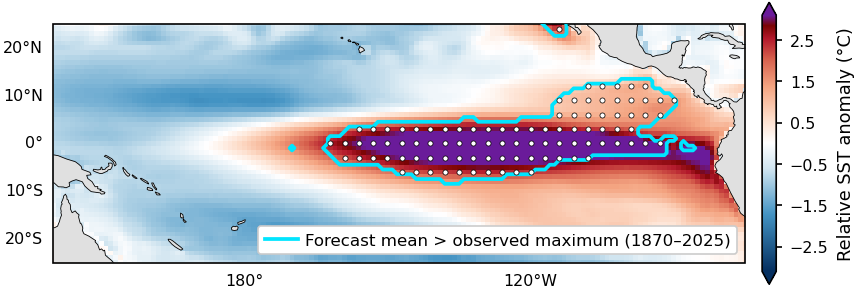

In [29]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- observed reference: ERSSTv5 only, through 2026 ---
f_e = obs_djf_rel_fields(OBS)
yrs = [int(y) for y in f_e.enso_year.values if 1870 <= y <= 2027]
obs_yearly = f_e.sel(enso_year=yrs)
obs_max = obs_yearly.max("enso_year")
print(f"ERSSTv5 DJF fields: {len(yrs)} ENSO years ({yrs[0]}\u2013{yrs[-1]})")

# --- symmetric colormap: blue | white at 0 | red -> purple ---
cmap_hot = LinearSegmentedColormap.from_list("relsst", [
    (0.00, "#053061"), (0.22, "#4393c3"), (0.40, "#d1e5f0"),
    (0.50, "#ffffff"),
    (0.60, "#fddbc7"), (0.72, "#f4a582"), (0.83, "#d6604d"),
    (0.91, "#b2182b"), (0.96, "#7a0403"), (1.00, "#6a1b9a")])
VLIM = 3.1
norm = Normalize(vmin=-VLIM, vmax=VLIM)

exceed = (fcst_rel > obs_max).astype(float)
print(f"{100*float(exceed.sel(lat=slice(-20,20)).mean()):.1f}% of the tropical band "
      f"exceeds anything observed since {yrs[0]}")

proj = ccrs.PlateCarree(central_longitude=180)
fig, ax = plt.subplots(figsize=(DOUBLE_COL*0.85, 62*MM), subplot_kw={"projection": proj})
p = ax.pcolormesh(fcst_rel.lon, fcst_rel.lat, fcst_rel, cmap=cmap_hot, norm=norm,
                  shading="auto", transform=ccrs.PlateCarree())

ax.contour(exceed.lon, exceed.lat, exceed, levels=[0.5], colors="#00e5ff",
           linewidths=1.8, transform=ccrs.PlateCarree(), zorder=4)
sub = exceed.isel(lat=slice(None,None,3), lon=slice(None,None,3))
yy, xx = np.meshgrid(sub.lat, sub.lon, indexing="ij")
m = (sub > 0.5).values
ax.scatter(xx[m], yy[m], s=6, c="w", edgecolor="k", lw=0.35,
           transform=ccrs.PlateCarree(), zorder=5)

ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=2)
ax.coastlines(lw=0.4, zorder=7)
# ax.plot([190,240,240,190,190], [-5,-5,5,5,-5], transform=ccrs.PlateCarree(),
#         color="k", lw=1.0, zorder=8)
ax.set_extent([140, 285, -25, 25], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, alpha=0); gl.top_labels = gl.right_labels = False

cb = fig.colorbar(p, ax=ax, orientation="vertical", shrink=0.85, pad=0.02,
                  extend="both", ticks=np.arange(-3.5, 3.6, 1.0))
cb.set_label("Relative SST anomaly (\u00b0C)")

ax.legend(handles=[Line2D([0],[0], color="#00e5ff", lw=1.8,
                          label=f"Forecast mean > observed maximum ({yrs[0]}\u2013{yrs[-1]})")],
          loc="lower right", fontsize=8, frameon=True, framealpha=1.0)
plt.tight_layout()

In [30]:
def area_frac(mask, lat=slice(None), lon=slice(None)):
    """Cosine-weighted percentage of area where mask is True."""
    m = mask.sel(lat=lat, lon=lon)
    w = np.cos(np.deg2rad(m.lat))
    return 100 * float(m.weighted(w).mean(("lat", "lon")))

exceed = (fcst_rel > obs_max)

regions = {
    "Nino-3.4 (5S-5N, 170-120W)":       dict(lat=slice(-5, 5),   lon=slice(190, 240)),
    "equatorial Pacific (5S-5N)":       dict(lat=slice(-5, 5),   lon=slice(140, 280)),
    "tropical Pacific (15S-15N)":       dict(lat=slice(-15, 15), lon=slice(140, 280)),
    "tropical Pacific (20S-20N)":       dict(lat=slice(-20, 20), lon=slice(120, 285)),
    "tropical band (20S-20N, all lon)": dict(lat=slice(-20, 20), lon=slice(0, 360)),
}
for name, box in regions.items():
    print(f"  {name:34s} {area_frac(exceed, **box):5.1f}%")

  Nino-3.4 (5S-5N, 170-120W)          72.6%
  equatorial Pacific (5S-5N)          41.1%
  tropical Pacific (15S-15N)          19.7%
  tropical Pacific (20S-20N)          12.8%
  tropical band (20S-20N, all lon)     6.0%


obs max: 2.1% of tropical band has ≥66% members exceeding
obs p95: 10.1% of tropical band has ≥66% members exceeding


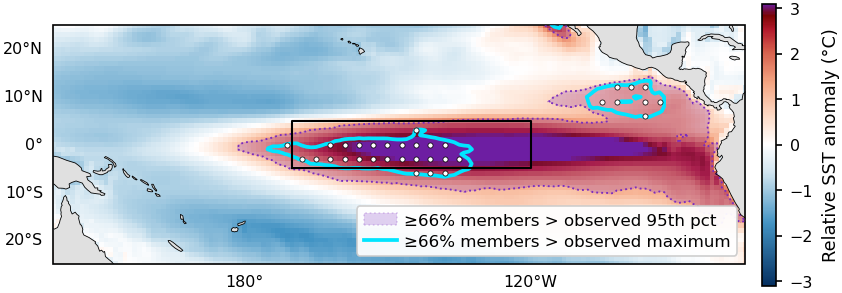

In [74]:
# --- observed reference levels (per gridpoint, across all ENSO years) ---
obs_p95 = obs_yearly.quantile(0.95, dim="enso_year").drop_vars("quantile")
obs_max = obs_yearly.max("enso_year")

THR = 0.66
frac_max = (fcst_mem > obs_max).mean("mem")
frac_p95 = (fcst_mem > obs_p95).mean("mem")
for nm, f in [("obs max", frac_max), ("obs p95", frac_p95)]:
    a = float((f.sel(lat=slice(-20,20)) >= THR).mean())
    print(f"{nm}: {100*a:.1f}% of tropical band has \u2265{THR:.0%} members exceeding")

# --- figure ---
fcst_rel = fcst_mem.mean("mem")
proj = ccrs.PlateCarree(central_longitude=180)
fig, ax = plt.subplots(figsize=(DOUBLE_COL*0.85, 62*MM), subplot_kw={"projection": proj})

# p = ax.pcolormesh(fcst_rel.lon, fcst_rel.lat, fcst_rel, cmap="RdBu_r",
#                   vmin=-3.1, vmax=3.1, shading="auto", transform=ccrs.PlateCarree())

p = ax.pcolormesh(fcst_rel.lon, fcst_rel.lat, fcst_rel, cmap=cmap_hot,
                  norm=norm, shading="auto", transform=ccrs.PlateCarree())

# wider criterion (p95): translucent overlay + thin outline
ax.contourf(frac_p95.lon, frac_p95.lat, frac_p95, levels=[THR, 1.01],
            colors=["#7b2cbf"], alpha=0.22, transform=ccrs.PlateCarree(), zorder=4)
ax.contour(frac_p95.lon, frac_p95.lat, frac_p95, levels=[THR], colors="#7b2cbf",
           linewidths=0.9, linestyles=":", transform=ccrs.PlateCarree(), zorder=5)

# stricter criterion (max): bold outline + white dots
ax.contour(frac_max.lon, frac_max.lat, frac_max, levels=[THR], colors="#00e5ff",
           linewidths=1.8, transform=ccrs.PlateCarree(), zorder=6)
sub = frac_max.isel(lat=slice(None,None,3), lon=slice(None,None,3))
yy, xx = np.meshgrid(sub.lat, sub.lon, indexing="ij")
m = (sub >= THR).values
ax.scatter(xx[m], yy[m], s=6, c="w", edgecolor="k", lw=0.35,
           transform=ccrs.PlateCarree(), zorder=7)

ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=2)
ax.coastlines(lw=0.4, zorder=9)
ax.plot([190,240,240,190,190], [-5,-5,5,5,-5], transform=ccrs.PlateCarree(),
        color="k", lw=1.0, zorder=10)
ax.set_extent([140, 285, -25, 25], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, alpha=0); gl.top_labels = gl.right_labels = False
cb = fig.colorbar(p, ax=ax, orientation="vertical", shrink=0.85, pad=0.02)
cb.set_label("Relative SST anomaly (\u00b0C)")

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#7b2cbf", alpha=0.22, edgecolor="#7b2cbf", ls=":",
          label=f"\u2265{THR:.0%} members > observed 95th pct"),
    Line2D([0],[0], color="#00e5ff", lw=1.8,
           label=f"\u2265{THR:.0%} members > observed maximum"),
], loc="lower right", fontsize=8, frameon=True, framealpha=0.95)
plt.tight_layout()

In [75]:
LATBAND = slice(-15, 15)
PAC     = slice(140, 285)
THR     = 0.66

def area_frac(mask, lat=LATBAND, lon=slice(None)):
    """Cosine-weighted fraction of area where mask is True."""
    m = mask.sel(lat=lat, lon=lon)
    w = np.cos(np.deg2rad(m.lat))
    return float(m.weighted(w).mean(("lat", "lon")))

fcst_mean = fcst_mem.mean("mem")
rows = [
    ("forecast mean > obs max",        fcst_mean > obs_max),
    ("forecast mean > obs 95th pct",   fcst_mean > obs_p95),
    (f"\u2265{THR:.0%} members > obs max",      frac_max >= THR),
    (f"\u2265{THR:.0%} members > obs 95th pct", frac_p95 >= THR),
]

print(f"{'criterion':32s} {'15S-15N':>9s} {'Pacific':>9s}")
for label, mask in rows:
    print(f"  {label:30s} {100*area_frac(mask):8.1f}% {100*area_frac(mask, lon=PAC):8.1f}%")

criterion                          15S-15N   Pacific
  forecast mean > obs max             6.0%     14.7%
  forecast mean > obs 95th pct       17.3%     39.6%
  ≥66% members > obs max              2.9%      7.0%
  ≥66% members > obs 95th pct        13.5%     33.1%


In [88]:
# 1. is the forecast field consistent with the index?
n34_map = float(fcst_rel.sel(lat=slice(-5,5), lon=slice(190,240)).mean())
print(f"map Nino3.4 (unscaled rel.): {n34_map:.2f}")
print(f"expected ~ f2026 best / SCALE = {f2026['best']/SCALE:.2f}")

# 2. how much does the observational reference differ?
obs_max_e = obs_djf_rel_fields("ERSSTv5").sel(enso_year=yrs).max("enso_year")
box = dict(lat=slice(-5,5), lon=slice(190,240))
print(f"\nobs_max in Nino3.4  4-product: {float(obs_max.sel(**box).mean()):.2f}"
      f"   ERSSTv5 only: {float(obs_max_e.sel(**box).mean()):.2f}")
print(f"exceedance with ERSSTv5 reference: "
      f"{area_frac(fcst_rel > obs_max_e, **box):.1f}%")

map Nino3.4 (unscaled rel.): 2.70
expected ~ f2026 best / SCALE = 2.55

obs_max in Nino3.4  4-product: 2.38   ERSSTv5 only: 2.38
exceedance with ERSSTv5 reference: 72.6%


In [89]:
print("identical:", bool(obs_max.equals(obs_max_e)))
print("max abs diff:", float(abs(obs_max - obs_max_e).max()))

identical: True
max abs diff: 0.0
